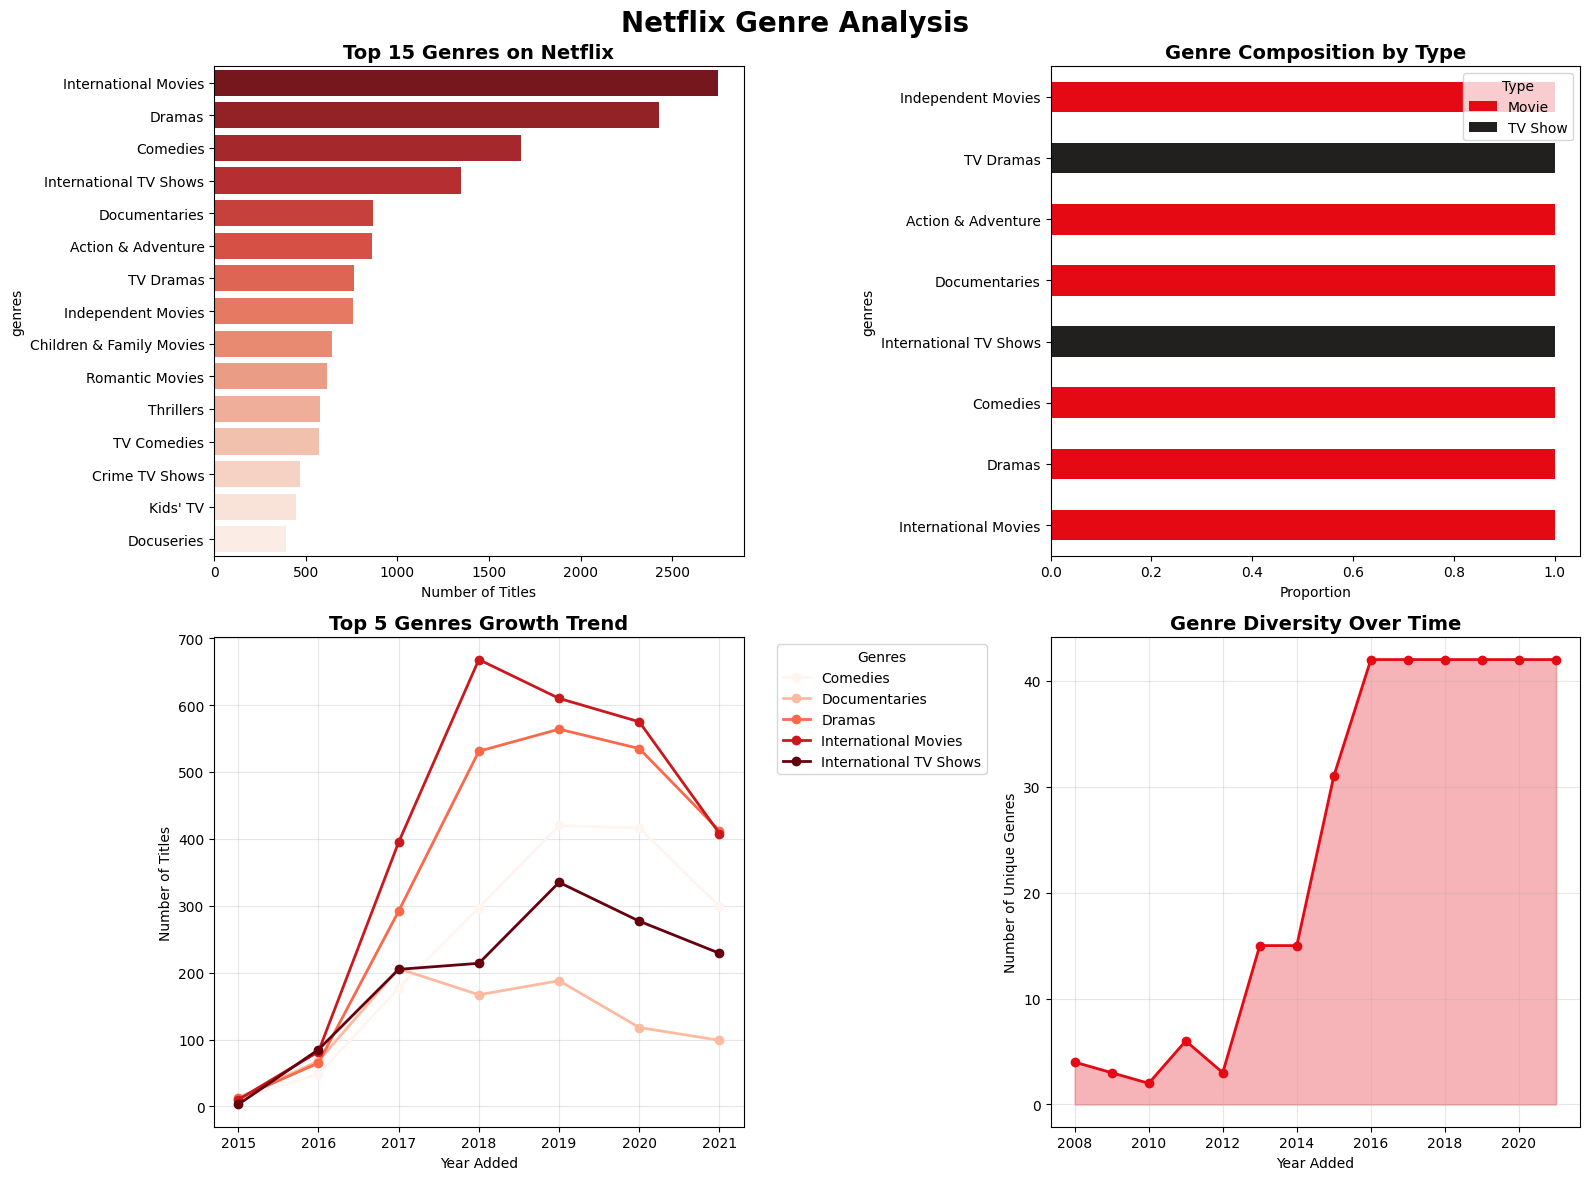


🎭 KEY GENRE INSIGHTS:
--------------------------------------------------
Total unique genres: 42

Top 5 genres:
1. International Movies: 2752 titles (31.3%)
2. Dramas: 2426 titles (27.6%)
3. Comedies: 1674 titles (19.0%)
4. International TV Shows: 1349 titles (15.3%)
5. Documentaries: 869 titles (9.9%)


In [4]:
# Cell 5: Genre Analysis
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

# Load your data if not already loaded
df = pd.read_csv('D:/Netflix content strategy analysis/data/processed data/netflix_clean_data.csv')

# First, explode the genres column to analyze individual genres
df_genres = df.copy()
df_genres['genres'] = df_genres['listed_in'].str.split(', ')
genre_exploded = df_genres.explode('genres')
genre_exploded['genres'] = genre_exploded['genres'].str.strip()

# Create genre analysis visualizations
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Netflix Genre Analysis', fontsize=20, fontweight='bold')

# 1. Top genres overall
ax1 = plt.subplot(2, 2, 1)
top_genres = genre_exploded['genres'].value_counts().head(15)
sns.barplot(y=top_genres.index, x=top_genres.values, palette='Reds_r', ax=ax1)
ax1.set_xlabel('Number of Titles')
ax1.set_title('Top 15 Genres on Netflix', fontsize=14, fontweight='bold')

# 2. Genre distribution by content type
ax2 = plt.subplot(2, 2, 2)
genre_type = pd.crosstab(genre_exploded['genres'], genre_exploded['type'])
genre_type_pct = genre_type.div(genre_type.sum(1), axis=0)
top_genres_list = top_genres.index[:8].tolist()
genre_type_pct.loc[top_genres_list].plot(kind='barh', stacked=True, 
                                         color=['#E50914', '#221f1f'], ax=ax2)
ax2.set_xlabel('Proportion')
ax2.set_title('Genre Composition by Type', fontsize=14, fontweight='bold')
ax2.legend(title='Type')

# 3. Genre growth trends (top 5 genres over time)
ax3 = plt.subplot(2, 2, 3)
top_5_genres = top_genres.index[:5].tolist()
genre_year = genre_exploded[genre_exploded['year_added'] >= 2015]
genre_year = genre_year[genre_year['genres'].isin(top_5_genres)]

genre_trends = genre_year.groupby(['year_added', 'genres']).size().unstack().fillna(0)
genre_trends.plot(marker='o', ax=ax3, linewidth=2, colormap='Reds')
ax3.set_xlabel('Year Added')
ax3.set_ylabel('Number of Titles')
ax3.set_title('Top 5 Genres Growth Trend', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(title='Genres', bbox_to_anchor=(1.05, 1))

# 4. Genre diversity over time
ax4 = plt.subplot(2, 2, 4)
genre_diversity = genre_exploded.groupby('year_added')['genres'].nunique()
ax4.plot(genre_diversity.index, genre_diversity.values, marker='o', 
         color='#E50914', linewidth=2, markersize=6)
ax4.fill_between(genre_diversity.index, genre_diversity.values, alpha=0.3, color='#E50914')
ax4.set_xlabel('Year Added')
ax4.set_ylabel('Number of Unique Genres')
ax4.set_title('Genre Diversity Over Time', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('D:/Netflix content strategy analysis/outputs/figures/genre_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print genre insights
print("\n🎭 KEY GENRE INSIGHTS:")
print("-" * 50)
print(f"Total unique genres: {genre_exploded['genres'].nunique()}")
print(f"\nTop 5 genres:")
for i, (genre, count) in enumerate(top_genres.head(5).items(), 1):
    print(f"{i}. {genre}: {count} titles ({count/len(df)*100:.1f}%)")

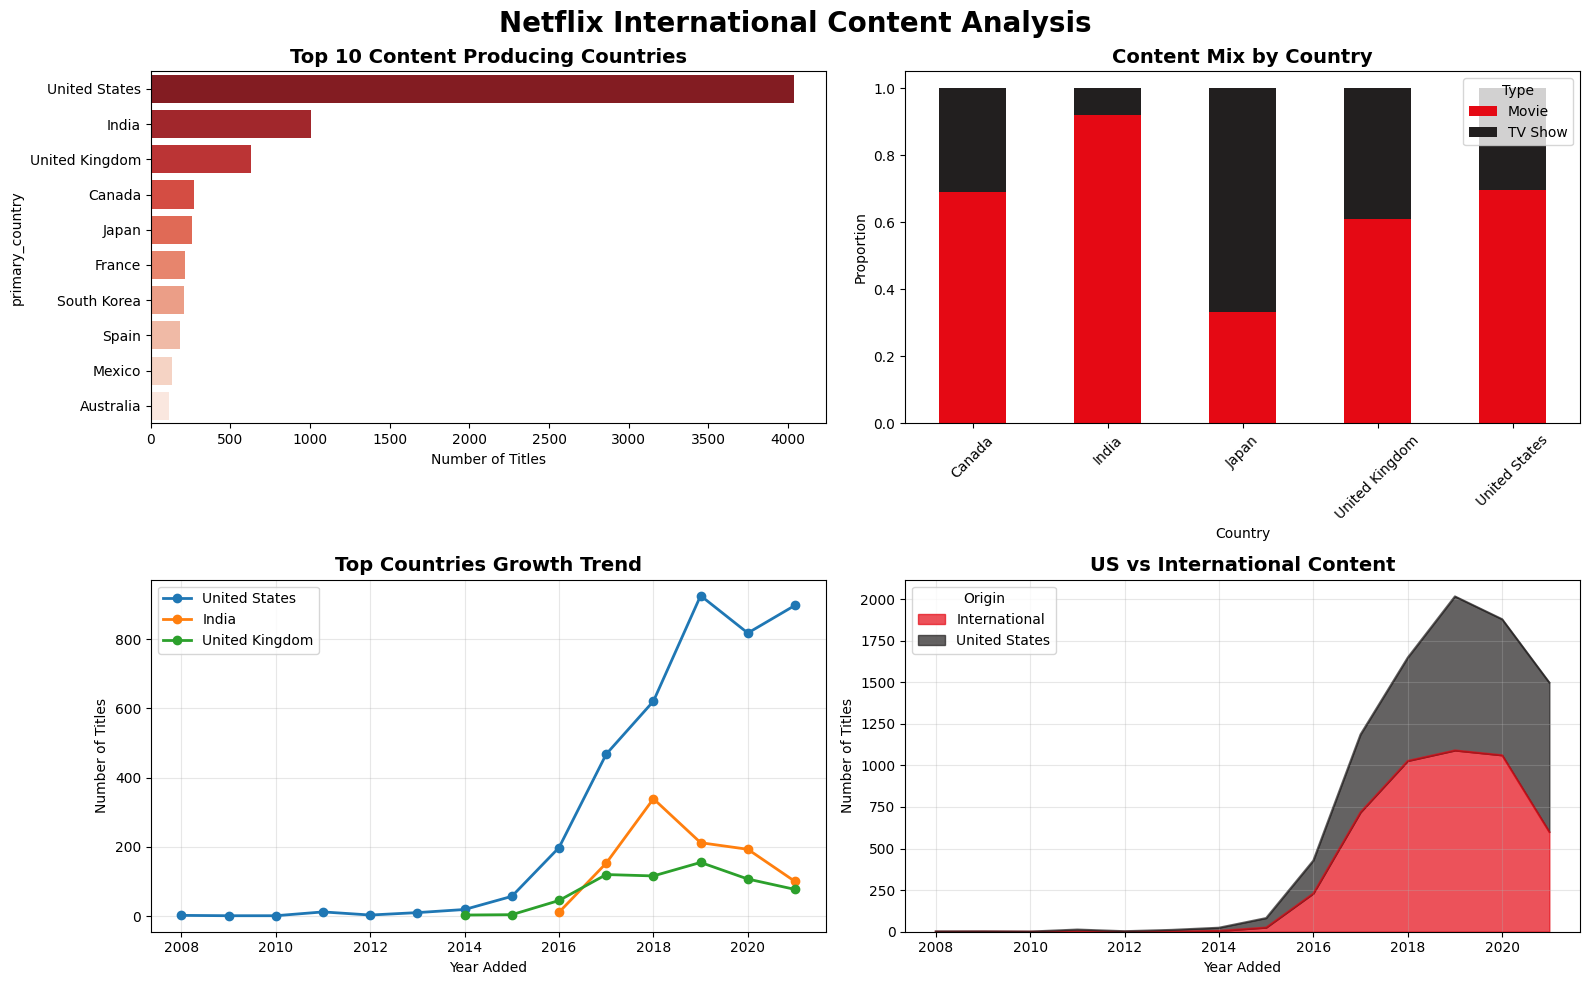


🌍 KEY COUNTRY INSIGHTS:
--------------------------------------------------
United States share: 45.9%
International share: 54.1%

Top 5 non-US producers:
  India: 1008 titles
  United Kingdom: 627 titles
  Canada: 271 titles
  Japan: 257 titles
  France: 212 titles


In [5]:
# Cell 6: Country Analysis
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Netflix International Content Analysis', fontsize=20, fontweight='bold')

# Determine which country column to use
country_col = 'primary_country' if 'primary_country' in df.columns else 'country'

# 1. Top producing countries
ax1 = plt.subplot(2, 2, 1)
top_countries = df[country_col].value_counts().head(10)
sns.barplot(y=top_countries.index, x=top_countries.values, palette='Reds_r', ax=ax1)
ax1.set_xlabel('Number of Titles')
ax1.set_title('Top 10 Content Producing Countries', fontsize=14, fontweight='bold')

# 2. Content mix by country (top 5 countries)
ax2 = plt.subplot(2, 2, 2)
top_5_countries = top_countries.index[:5].tolist()
country_data = df[df[country_col].isin(top_5_countries)]
country_type = pd.crosstab(country_data[country_col], country_data['type'])
country_type_pct = country_type.div(country_type.sum(1), axis=0)
country_type_pct.plot(kind='bar', stacked=True, color=['#E50914', '#221f1f'], ax=ax2)
ax2.set_xlabel('Country')
ax2.set_ylabel('Proportion')
ax2.set_title('Content Mix by Country', fontsize=14, fontweight='bold')
ax2.legend(title='Type')
ax2.tick_params(axis='x', rotation=45)

# 3. Country growth over time (top countries)
ax3 = plt.subplot(2, 2, 3)
for country in top_5_countries[:3]:  # Show top 3 for clarity
    country_trend = df[df[country_col] == country].groupby('year_added').size()
    ax3.plot(country_trend.index, country_trend.values, marker='o', linewidth=2, 
             label=country)
ax3.set_xlabel('Year Added')
ax3.set_ylabel('Number of Titles')
ax3.set_title('Top Countries Growth Trend', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. US vs International content over time
ax4 = plt.subplot(2, 2, 4)
df['content_origin'] = df[country_col].apply(
    lambda x: 'United States' if 'United States' in str(x) else 'International'
)
origin_trend = df.groupby(['year_added', 'content_origin']).size().unstack().fillna(0)
origin_trend.plot(kind='area', stacked=True, color=['#E50914', '#221f1f'], 
                  alpha=0.7, ax=ax4)
ax4.set_xlabel('Year Added')
ax4.set_ylabel('Number of Titles')
ax4.set_title('US vs International Content', fontsize=14, fontweight='bold')
ax4.legend(title='Origin')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('D:/Netflix content strategy analysis/outputs/figures/country_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print country insights
print("\n🌍 KEY COUNTRY INSIGHTS:")
print("-" * 50)
us_share = (df[country_col].str.contains('United States', na=False).sum() / len(df)) * 100
print(f"United States share: {us_share:.1f}%")
print(f"International share: {100 - us_share:.1f}%")
print(f"\nTop 5 non-US producers:")
non_us = df[~df[country_col].str.contains('United States', na=False)][country_col].value_counts().head(5)
for country, count in non_us.items():
    print(f"  {country}: {count} titles")

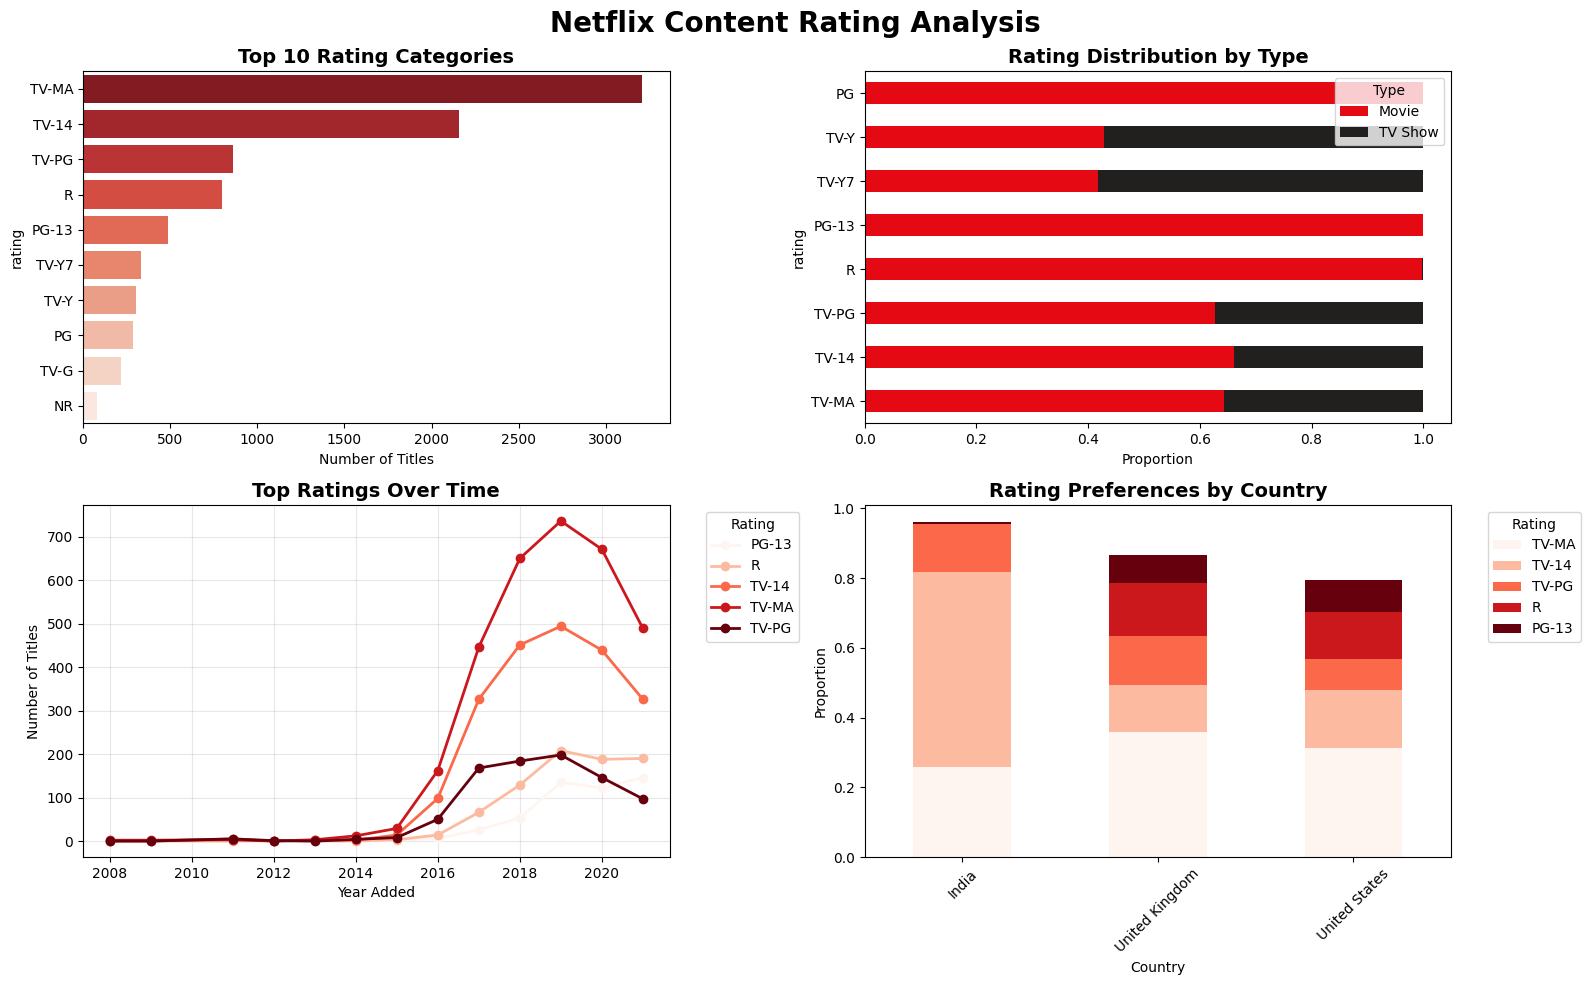


🎬 KEY RATING INSIGHTS:
--------------------------------------------------
Mature content (TV-MA/R/NC-17): 4007 (45.6%)
Family-friendly content: 967 (11.0%)


In [6]:
# Cell 7: Rating Analysis
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Netflix Content Rating Analysis', fontsize=20, fontweight='bold')

# 1. Rating distribution
ax1 = plt.subplot(2, 2, 1)
rating_counts = df['rating'].value_counts().head(10)
sns.barplot(y=rating_counts.index, x=rating_counts.values, palette='Reds_r', ax=ax1)
ax1.set_xlabel('Number of Titles')
ax1.set_title('Top 10 Rating Categories', fontsize=14, fontweight='bold')

# 2. Ratings by content type
ax2 = plt.subplot(2, 2, 2)
rating_type = pd.crosstab(df['rating'], df['type'])
rating_type_pct = rating_type.div(rating_type.sum(1), axis=0)
top_ratings = rating_counts.index[:8].tolist()
rating_type_pct.loc[top_ratings].plot(kind='barh', stacked=True,
                                       color=['#E50914', '#221f1f'], ax=ax2)
ax2.set_xlabel('Proportion')
ax2.set_title('Rating Distribution by Type', fontsize=14, fontweight='bold')
ax2.legend(title='Type')

# 3. Rating trends over time
ax3 = plt.subplot(2, 2, 3)
top_ratings_5 = rating_counts.index[:5].tolist()
rating_time = df[df['rating'].isin(top_ratings_5)]
rating_trends = rating_time.groupby(['year_added', 'rating']).size().unstack().fillna(0)
rating_trends.plot(marker='o', ax=ax3, linewidth=2, colormap='Reds')
ax3.set_xlabel('Year Added')
ax3.set_ylabel('Number of Titles')
ax3.set_title('Top Ratings Over Time', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(title='Rating', bbox_to_anchor=(1.05, 1))

# 4. Rating distribution by country (top 3 countries)
ax4 = plt.subplot(2, 2, 4)
top_3_countries = df[country_col].value_counts().index[:3].tolist()
rating_country_data = df[df[country_col].isin(top_3_countries)]
rating_country = pd.crosstab(rating_country_data[country_col], 
                             rating_country_data['rating'])
rating_country_pct = rating_country.div(rating_country.sum(1), axis=0)
rating_country_pct[top_ratings_5].plot(kind='bar', stacked=True, colormap='Reds', ax=ax4)
ax4.set_xlabel('Country')
ax4.set_ylabel('Proportion')
ax4.set_title('Rating Preferences by Country', fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
ax4.legend(title='Rating', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('D:/Netflix content strategy analysis/outputs/figures/rating_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🎬 KEY RATING INSIGHTS:")
print("-" * 50)
mature_content = df[df['rating'].isin(['TV-MA', 'R', 'NC-17'])].shape[0]
print(f"Mature content (TV-MA/R/NC-17): {mature_content} ({mature_content/len(df)*100:.1f}%)")
family_friendly = df[df['rating'].isin(['TV-Y', 'TV-Y7', 'G', 'PG'])].shape[0]
print(f"Family-friendly content: {family_friendly} ({family_friendly/len(df)*100:.1f}%)")

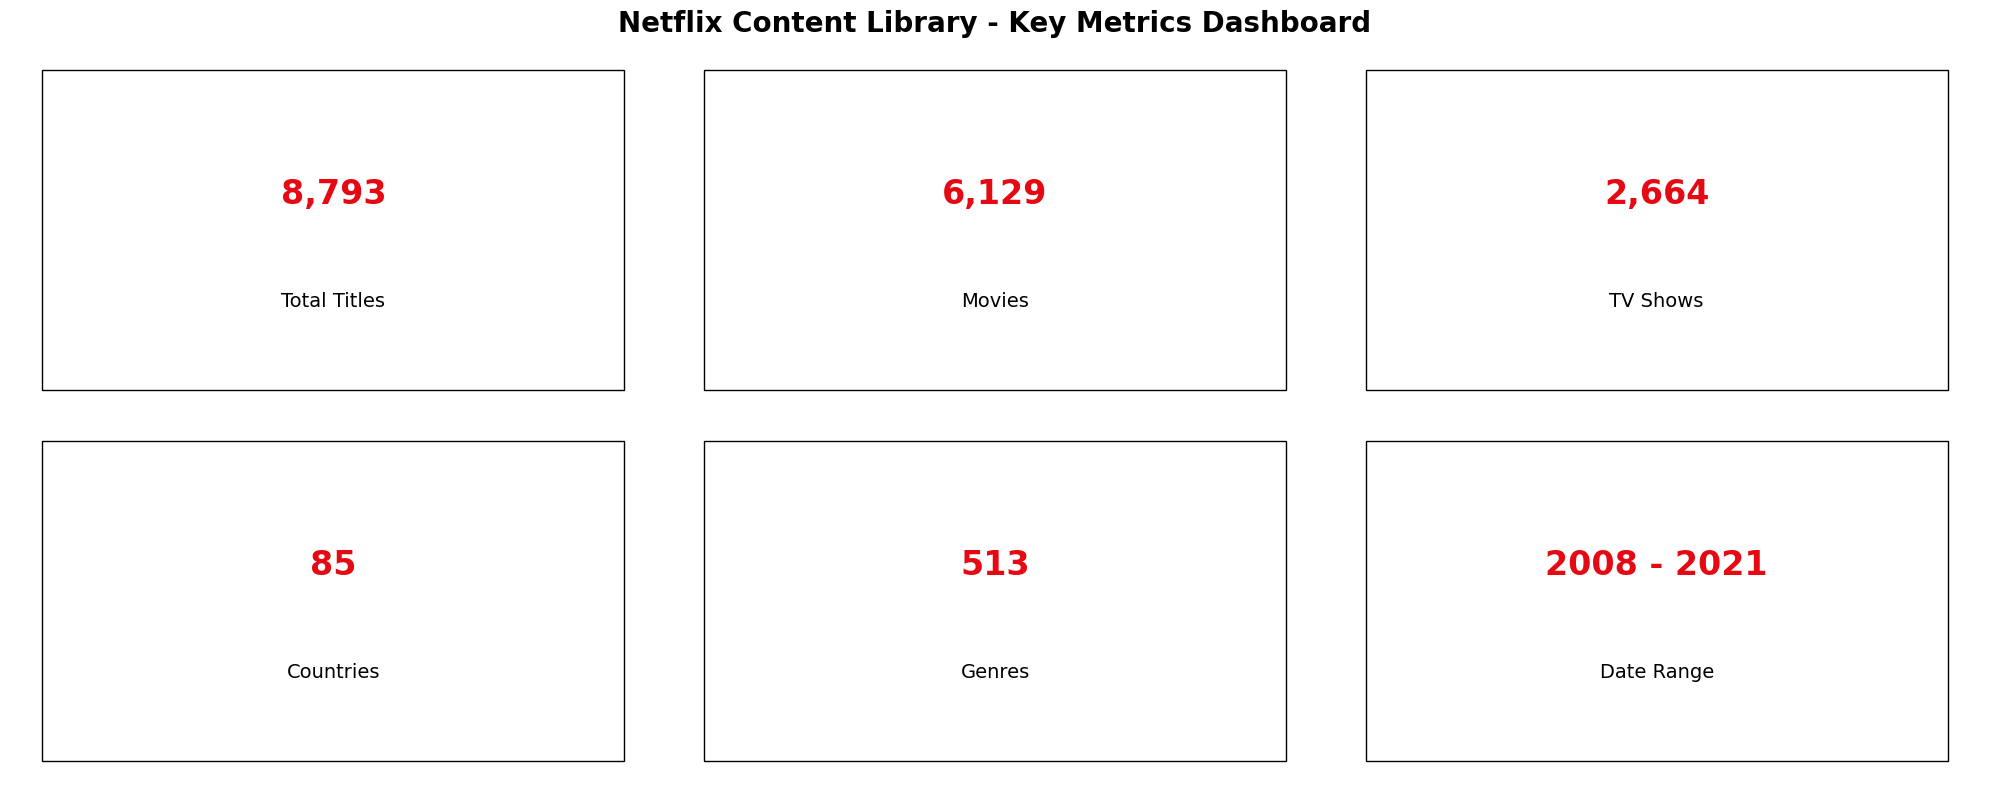

In [7]:
# Cell 8: Create a summary dashboard with key metrics
fig = plt.figure(figsize=(20, 8))
fig.suptitle('Netflix Content Library - Key Metrics Dashboard', fontsize=20, fontweight='bold')

# Create a 2x3 grid for metrics
metrics = [
    ('Total Titles', f"{len(df):,}"),
    ('Movies', f"{len(df[df['type'] == 'Movie']):,}"),
    ('TV Shows', f"{len(df[df['type'] == 'TV Show']):,}"),
    ('Countries', f"{df[country_col].nunique()}"),
    ('Genres', f"{df['listed_in'].nunique()}"),
    ('Date Range', f"{df['year_added'].min()} - {df['year_added'].max()}")
]

for i, (label, value) in enumerate(metrics, 1):
    ax = plt.subplot(2, 3, i)
    ax.text(0.5, 0.6, value, fontsize=24, fontweight='bold', 
            ha='center', va='center', color='#E50914')
    ax.text(0.5, 0.3, label, fontsize=14, ha='center', va='center')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # Add a border
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, 
                                fill=False, edgecolor='black', linewidth=1))

plt.tight_layout()
plt.savefig('D:/Netflix content strategy analysis/outputs/figures/dashboard_summary.png', dpi=300, bbox_inches='tight')
plt.show()